# DSC 80 Midterm Question 13

##Generate Data Set
### Mean Departure Delays
    "AA": 30.19,
    "DL": 25.85,
    "WN": 28.05,
    "F9": 20.00

In [2]:
import numpy as np
import pandas as pd

# Number of flights
N = 1_000_000

# Airlines and their target means
airlines = {
    "AA": 30.19,
    "DL": 25.85,
    "WN": 28.05,
    "F9": 20.00
}

# Flights per airline
flights_per_airline = N // len(airlines)

# Collect all flights
all_flights = []
np.random.seed(42)

for carrier, mean_delay in airlines.items():
    # Use a gamma distribution to simulate right-skewed delays
    # shape parameter k controls skewness (smaller k = more skew)
    shape_k = 2.0
    scale_theta = mean_delay / shape_k  # so mean ≈ k*θ = mean_delay

    delays = np.random.gamma(shape=shape_k, scale=scale_theta, size=flights_per_airline)

    # Clip extreme values (optional, to avoid absurd delays >1000 mins)
    delays = np.clip(delays, a_min=-15, a_max=600)

    df = pd.DataFrame({
        "Carrier": carrier,
        "DepDelay": delays
    })
    all_flights.append(df)

# Combine
flights_df = pd.concat(all_flights, ignore_index=True)

# Check actual means
print(flights_df.groupby("Carrier")["DepDelay"].mean().round(2))


Carrier
AA    30.24
DL    25.83
F9    20.00
WN    27.93
Name: DepDelay, dtype: float64


## Drop 250,000 disproportionately from airlines

In [3]:
import pandas as pd

# Number of rows to delete
N_delete = 250_000

# Define deletion quotas by carrier
deletion_plan = {
    "AA": int(0.10 * N_delete),  # 25,000
    "DL": int(0.10 * N_delete),  # 25,000
    "WN": int(0.10 * N_delete),  # 25,000
    "F9": int(0.70 * N_delete)   # 175,000
}

# Create an index list of rows to drop
drop_indices = []

for carrier, n in deletion_plan.items():
    # Sample n rows from each carrier
    idx = flights_df[flights_df["Carrier"] == carrier].sample(n=n, random_state=42).index
    drop_indices.extend(idx)

# Drop the sampled rows
flights_df_dropped = flights_df.drop(index=drop_indices)

# Check new sizes per carrier
print(flights_df_dropped["Carrier"].value_counts())
print("Original size:", len(flights_df))
print("New size:", len(flights_df_dropped))


Carrier
AA    225000
DL    225000
WN    225000
F9     75000
Name: count, dtype: int64
Original size: 1000000
New size: 750000


## Plot after deletion of missing rows

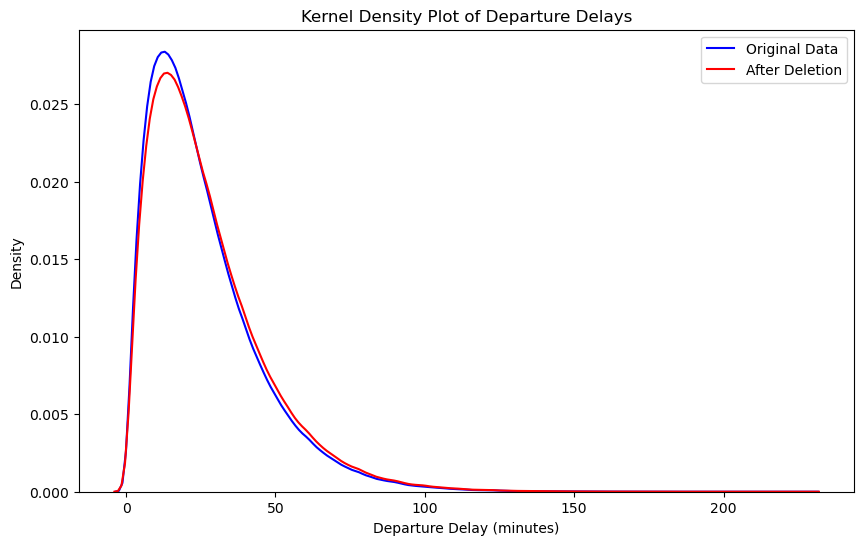

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# KDE plot of original data
plt.figure(figsize=(10,6))
sns.kdeplot(flights_df["DepDelay"], label="Original Data", color="blue")

# KDE plot of data after deletion
sns.kdeplot(flights_df_dropped["DepDelay"], label="After Deletion", color="red")

plt.title("Kernel Density Plot of Departure Delays")
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Density")
plt.legend()
plt.show()


## Conditional Impuation of MAR data

In [8]:
import numpy as np

# Copy the dataset
flights_with_na = flights_df.copy()

# Introduce NaN in the same rows that were previously deleted
flights_with_na.loc[drop_indices, "DepDelay"] = np.nan


In [9]:
# Impute missing values with carrier-specific means
flights_imputed = flights_with_na.copy()

flights_imputed["DepDelay"] = flights_imputed.groupby("Carrier")["DepDelay"] \
    .transform(lambda s: s.fillna(s.mean()))


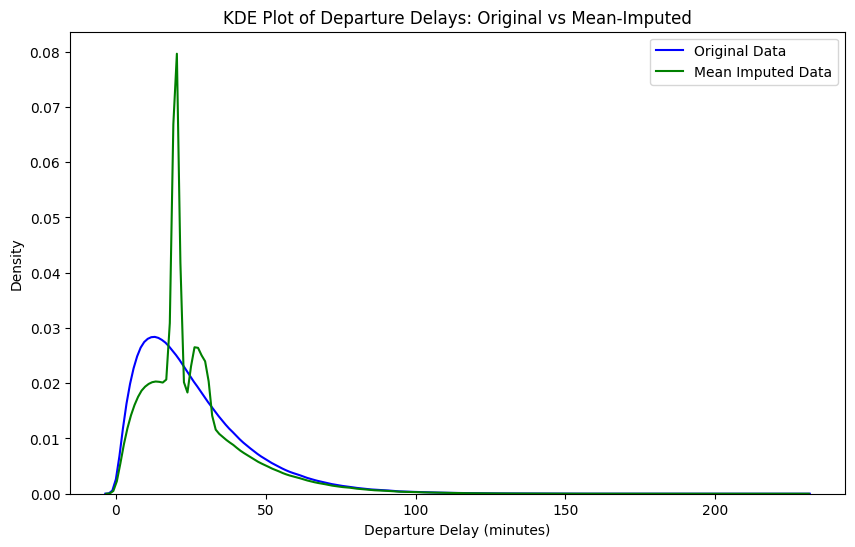

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Original data KDE
sns.kdeplot(flights_df["DepDelay"], label="Original Data", color="blue")

# Mean-imputed data KDE
sns.kdeplot(flights_imputed["DepDelay"], label="Mean Imputed Data", color="green")

plt.title("KDE Plot of Departure Delays: Original vs Mean-Imputed")
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Density")
plt.legend()
plt.show()


## Probabilistic Imputation of MAR Data

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Copy the dataset with NaNs in DepDelay
flights_with_na = flights_df.copy()
flights_with_na.loc[drop_indices, "DepDelay"] = np.nan

# Function: probabilistic imputation (sample from observed distribution)
def impute_by_sampling(group):
    vals = group.dropna().values
    mask = group.isna()
    n_missing = mask.sum()
    if n_missing > 0:
        # Randomly sample from observed values (bootstrap)
        group[mask] = np.random.choice(vals, size=n_missing, replace=True)
    return group

# Apply per airline
flights_imputed_prob = flights_with_na.copy()
flights_imputed_prob["DepDelay"] = flights_imputed_prob.groupby("Carrier")["DepDelay"].transform(impute_by_sampling)


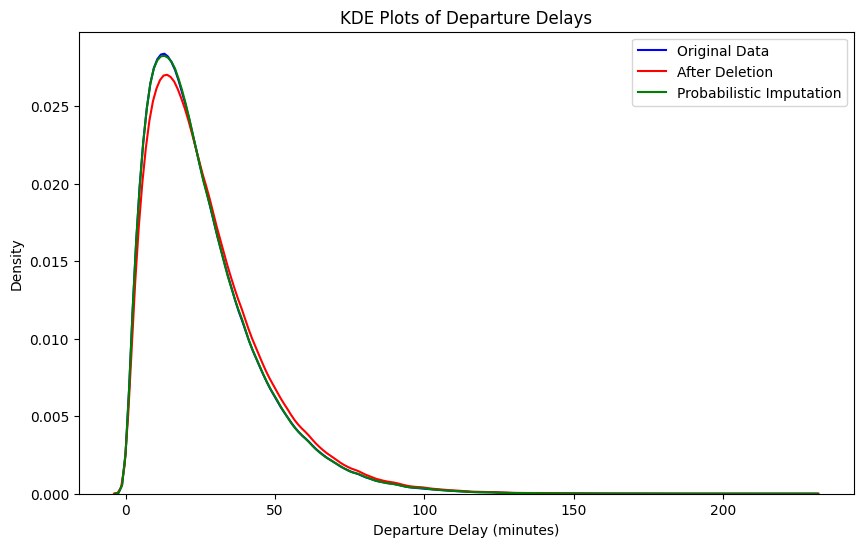

In [ ]:
plt.figure(figsize=(10,6))

# Original KDE
sns.kdeplot(flights_df["DepDelay"], label="Original Data", color="blue")

# After deletion KDE
sns.kdeplot(flights_df_dropped["DepDelay"], label="After Deletion", color="red")

# After probabilistic imputation KDE
sns.kdeplot(flights_imputed_prob["DepDelay"], label="Probabilistic Imputation", color="green")

plt.title("KDE Plots of Departure Delays")
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Density")
plt.legend()
plt.show()
